# Model comparison: ANN, 1-D CNN and QNN

Collects the saved results of every notebook into one place. **Nothing is retrained here**, so it runs in seconds.

Run order of the project:

| # | Notebook | Produces (in `results/` and `models/`) |
|---|---|---|
| 1 | `01_preprocess.ipynb` | `data/traffic_flow_preprocessed.npz` |
| 2 | `02_baselines.ipynb` | `baseline_results.json` |
| 3 | `03_train_ann.ipynb` | `ann_results.json`, `ann_predictions.npz`, `ann_model.keras` |
| 4 | `04_train_cnn.ipynb` | `cnn_results.json`, `cnn_predictions.npz`, `cnn_model.keras` |
| 5 | `05_train_qnn.ipynb` | `qnn_results.json`, `qnn_predictions.npz`, `qnn.weights.h5` |

Any model whose files are missing is skipped with a note.

## 0 · Setup

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Paths
PROJECT = os.path.abspath(".")  # run the notebooks from the repository root
RESULTS_DIR = os.path.join(PROJECT, "results")

CLASS_NAMES = ["Low", "Medium", "High"]
MODELS = {                       # display name: (results file, predictions file)
    "ANN": (os.path.join(RESULTS_DIR, "ann_results.json"),
            os.path.join(RESULTS_DIR, "ann_predictions.npz")),
    "1-D CNN": (os.path.join(RESULTS_DIR, "cnn_results.json"),
                os.path.join(RESULTS_DIR, "cnn_predictions.npz")),
    "QNN (6 qubits)": (os.path.join(RESULTS_DIR, "qnn_results.json"),
                       os.path.join(RESULTS_DIR, "qnn_predictions.npz")),
}


def find(name):
    for path in (os.path.join(RESULTS_DIR, name), os.path.join(PROJECT, name)):
        if os.path.exists(path):
            return path
    return os.path.join(RESULTS_DIR, name)


def load_json(path):
    if not os.path.exists(path):
        print(f"  missing: {path}")
        return None
    with open(path) as f:
        return json.load(f)

MODELS = {name: (find(os.path.basename(r)), find(os.path.basename(p))) for name, (r, p) in MODELS.items()}
BASELINE_FILE = find("baseline_results.json")
print("Reading results from:", RESULTS_DIR)

Reading results from: E:\Traffic Flow Detection Using Neural Networks\results


## 1 · Forecasting models vs baselines

All of these solve the same task on the same test set: predict one sensor's flow class (Low / Medium / High) for the
next 5 minutes from its last 2 hours.

The baselines are simple rules with nothing learned. **The 15-min-average rule is the bar to beat.**

In [2]:
rows, kinds = {}, {}
for name, r in (load_json(BASELINE_FILE) or {}).items():
    rows[name] = {"accuracy": r["accuracy"], "macro_f1": r["macro_f1"]}
    kinds[name] = "baseline"

qnn = None
for name, (res_file, _) in MODELS.items():
    r = load_json(res_file)
    if r is None:
        continue
    rows[name] = {"accuracy": r["accuracy"], "macro_f1": r["macro_f1"], "mean_iou": r.get("mean_iou")}
    kinds[name] = "neural network"
    if "classical_control" in r:            # the QNN notebook also stores its classical control
        qnn = r
        rows["Classical control (6 units)"] = dict(r["classical_control"])
        kinds["Classical control (6 units)"] = "neural network"

table = pd.DataFrame(rows).T
table.insert(0, "type", pd.Series(kinds))
table = table.sort_values("accuracy", ascending=False)
table.style.format({"accuracy": "{:.4f}", "macro_f1": "{:.4f}", "mean_iou": "{:.4f}"}, na_rep="-")

,type,accuracy,macro_f1,mean_iou
1-D CNN,neural network,0.8918,0.8911,0.8073
ANN,neural network,0.8899,0.8893,0.8044
15-min average,baseline,0.8808,0.8804,-
Persistence,baseline,0.8728,0.8721,-
Logistic regression,baseline,0.8724,0.8717,-
QNN (6 qubits),neural network,0.8625,0.8625,0.7633
Classical control (6 units),neural network,0.8613,0.8610,-
Linear trend,baseline,0.8066,0.8043,-
Majority class,baseline,0.3363,0.1678,-


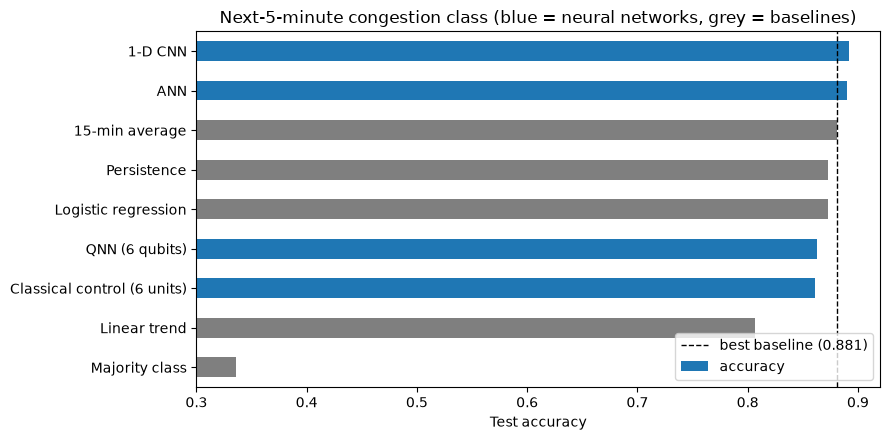

1-D CNN                      +1.11 points vs best baseline
ANN                          +0.91 points vs best baseline
QNN (6 qubits)               -1.83 points vs best baseline
Classical control (6 units)  -1.95 points vs best baseline


In [3]:
colors = ["tab:blue" if kinds[n] == "neural network" else "tab:gray" for n in table.index]
ax = table["accuracy"].plot.barh(figsize=(9, 4.5), color=colors)
ax.invert_yaxis()
ax.set_xlim(0.3, 0.92)
best_rule = table[table["type"] == "baseline"]["accuracy"].max()
ax.axvline(best_rule, color="black", ls="--", lw=1, label=f"best baseline ({best_rule:.3f})")
ax.set_xlabel("Test accuracy")
ax.set_title("Next-5-minute congestion class (blue = neural networks, grey = baselines)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

for name in table.index[table["type"] == "neural network"]:
    print(f"{name:<28} {(table.loc[name, 'accuracy'] - best_rule) * 100:+.2f} points vs best baseline")

## 2 · Where do the models make mistakes?

Confusion matrices as row percentages. For every model, the errors should sit next to the diagonal
(Low ↔ Medium, Medium ↔ High), and Medium, bounded on both sides, should be the hardest class.

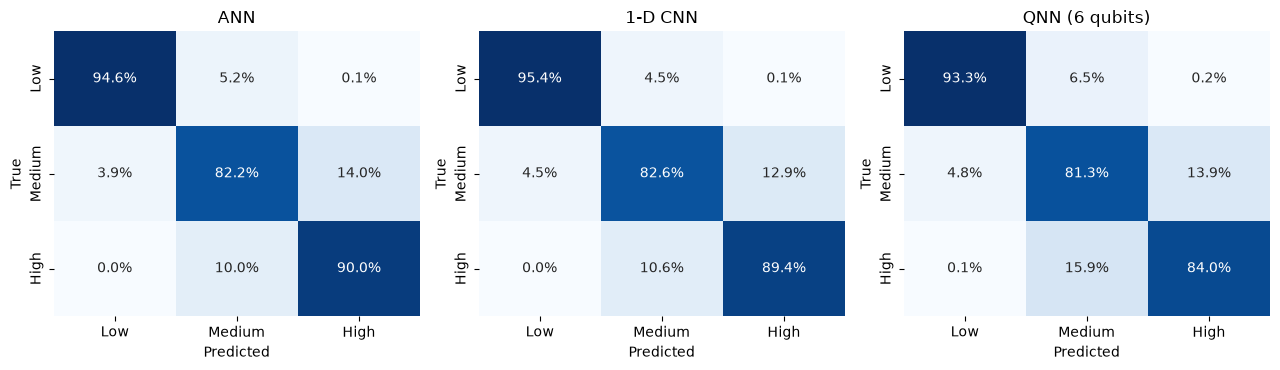

In [4]:
from sklearn.metrics import confusion_matrix

available = [(n, np.load(p)) for n, (_, p) in MODELS.items() if os.path.exists(p)]
fig, axes = plt.subplots(1, len(available), figsize=(4.3 * len(available), 3.8), squeeze=False)
for ax, (name, p) in zip(axes[0], available):
    cm = confusion_matrix(p["y_true"], p["y_pred"])
    sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt=".1%", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.tight_layout()
plt.show()

## 3 · Per-sensor accuracy

The same model can be excellent on one sensor and weak on another. Each box shows the spread of accuracy over the
170 sensors. A model that is better *everywhere* has its whole box shifted right, not just its median.

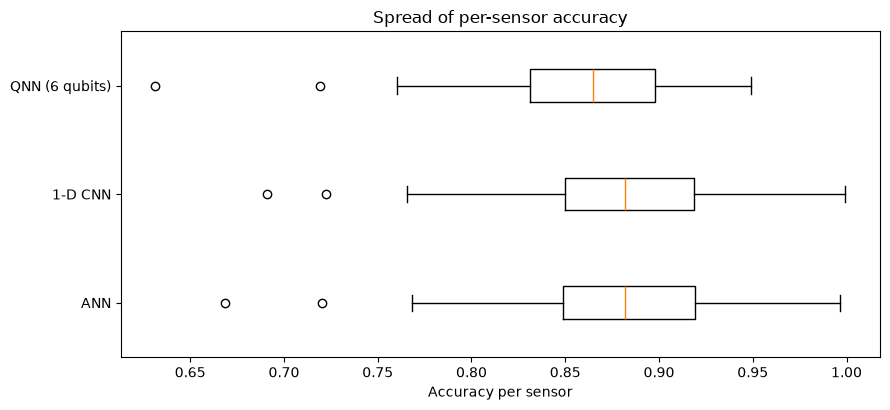

Hardest sensors (lowest accuracy, averaged over models):
155    0.663
147    0.721
49     0.765
94     0.782
40     0.783


In [5]:
per_sensor = {name: pd.Series(p["y_pred"] == p["y_true"]).groupby(p["sensor"]).mean()
              for name, p in available}
ps = pd.DataFrame(per_sensor)

plt.figure(figsize=(9, 3 + 0.4 * len(ps.columns)))
plt.boxplot(ps.values, orientation="horizontal", showfliers=True)
plt.yticks(range(1, len(ps.columns) + 1), ps.columns)
plt.xlabel("Accuracy per sensor"); plt.title("Spread of per-sensor accuracy")
plt.tight_layout()
plt.show()

print("Hardest sensors (lowest accuracy, averaged over models):")
print(ps.mean(axis=1).nsmallest(5).round(3).to_string())

## 4 · Summary for the paper

A short, honest reading of the numbers (check it against your own run):

* **Next-5-minute forecasting is dominated by persistence.** Traffic rarely changes class within 5 minutes, so
  simple rules already reach ≈ 88 %. The best neural networks add about **1 point** on top, and beat the best rule on
  roughly two-thirds of the sensors.
* **The 1-D CNN does slightly better than the ANN** (a few tenths of a point), because it reads the window as a time
  series instead of 72 independent numbers.
* **The QNN matches a classical model of the same size** (its classical control). There's no evidence of a quantum
  advantage. Both trail the full neural networks because they see only 6 PCA features and 50,000 training windows,
  a limit of simulating quantum circuits on a CPU.

In [6]:
# McNemar's test: are two models' accuracy differences statistically significant?
import numpy as np
from pathlib import Path
from scipy.stats import chi2

PROJECT = Path.cwd()  # run the notebooks from the repository root
DATA, RESULTS = PROJECT / "data", PROJECT / "results"

d = np.load(DATA / "traffic_flow_preprocessed.npz")
y_test, sensor = d["y_test"], d["sensor_test"]

# 15-min average rule (best baseline), rebuilt from the test windows
mean, std = d["feature_mean"], d["feature_std"]
flow_last3 = d["X_test_seq"][:, -3:, 0] * std[sensor, 0][:, None] + mean[sensor, 0][:, None]
avg = flow_last3.mean(axis=1)
low, high = d["low_th"][sensor], d["high_th"][sensor]
pred_avg15 = np.where(avg <= low, 0, np.where(avg <= high, 1, 2))

ann = np.load(RESULTS / "ann_predictions.npz")
cnn = np.load(RESULTS / "cnn_predictions.npz")
qnn = np.load(RESULTS / "qnn_predictions.npz")
assert (ann["y_true"] == y_test).all(), "prediction files are not in the same order as the test set"

preds = {"1-D CNN": cnn["y_pred"], "ANN": ann["y_pred"], "QNN": qnn["y_pred"],
         "Classical control": qnn["y_pred_control"], "15-min average": pred_avg15}

def mcnemar(a, b):
    right_a, right_b = preds[a] == y_test, preds[b] == y_test
    only_a = int((right_a & ~right_b).sum())       # a right, b wrong
    only_b = int((~right_a & right_b).sum())       # b right, a wrong
    stat = (abs(only_a - only_b) - 1) ** 2 / (only_a + only_b)   # with continuity correction
    log10_p = chi2.logsf(stat, df=1) / np.log(10)                # log scale: p can be ~1e-200
    return only_a, only_b, stat, log10_p

pairs = [("1-D CNN", "15-min average"), ("ANN", "15-min average"),
         ("1-D CNN", "ANN"), ("QNN", "Classical control")]

print(f"{'Comparison':<32}{'only A right':>13}{'only B right':>13}{'chi²':>9}   p-value")
for a, b in pairs:
    only_a, only_b, stat, lp = mcnemar(a, b)
    p = f"{10**lp:.1e}" if lp > -300 else f"≈ 1e{lp:.0f}"
    print(f"{a + ' vs ' + b:<32}{only_a:>13,}{only_b:>13,}{stat:>9.1f}   {p}")

Comparison                       only A right only B right     chi²   p-value


1-D CNN vs 15-min average              24,179       17,474   1079.0   1.2e-236
ANN vs 15-min average                  23,812       18,292    723.4   2.4e-159
1-D CNN vs ANN                         10,821        9,636     68.5   1.3e-16
QNN vs Classical control               10,484        9,737     27.5   1.6e-07


## McNemar's test

Accuracy alone doesn't show whether a gap between two models is real or noise. McNemar's test compares two models
on the **same** test windows and looks only at the windows where exactly one of them is right:
"only A right" vs "only B right". If both models were equally good, these two counts would be about equal.
The statistic is χ² = (|n_A - n_B| - 1)² / (n_A + n_B), with 1 degree of freedom.

With 606,390 test windows even a 0.1-point gap can be significant, so a small p-value means the difference is
**real**, not that it is **large**. The QNN vs classical-control result is the example: p ≈ 1.6e-7 for a 0.12-point gap.

## Headline figure

Test accuracy of every model on the same 606,390 test windows, zoomed to the top of the range so the 1-point gap between the networks and the best rule is visible. Dots, not bars, because the axis does not start at zero. The majority-class baseline (33.6 %) is off the left edge. Saved to `figures/accuracy_dotplot.png` for the README.

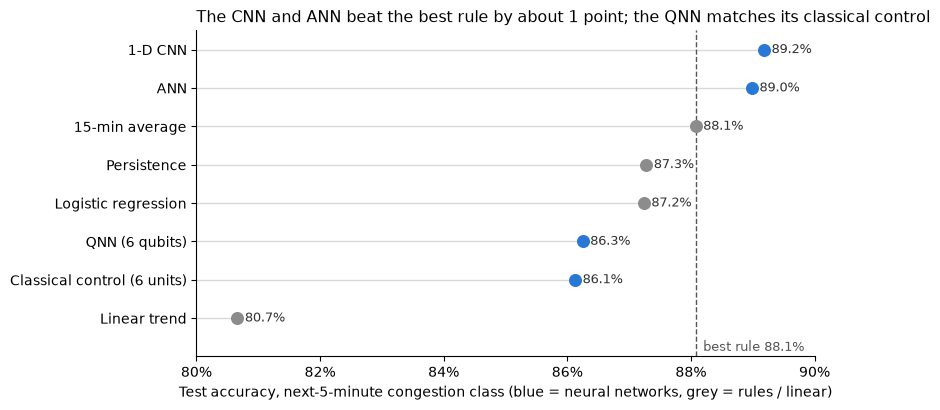

In [7]:
FIGURES = os.path.join(PROJECT, "figures")
os.makedirs(FIGURES, exist_ok=True)

with open(os.path.join(RESULTS_DIR, "baseline_results.json")) as f:
    rules = json.load(f)
rows = [(name, r["accuracy"], "rule / linear baseline") for name, r in rules.items() if name != "Majority class"]
for name, fn in (("1-D CNN", "cnn_results.json"), ("ANN", "ann_results.json")):
    with open(os.path.join(RESULTS_DIR, fn)) as f:
        rows.append((name, json.load(f)["accuracy"], "neural network"))
with open(os.path.join(RESULTS_DIR, "qnn_results.json")) as f:
    q = json.load(f)
rows += [("QNN (6 qubits)", q["accuracy"], "neural network"),
         ("Classical control (6 units)", q["classical_control"]["accuracy"], "neural network")]
acc = pd.DataFrame(rows, columns=["model", "accuracy", "kind"]).sort_values("accuracy")
best_rule = acc[acc.kind != "neural network"].accuracy.max()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for y, r in enumerate(acc.itertuples()):
    nn = r.kind == "neural network"
    ax.plot([0.80, r.accuracy], [y, y], color="#d9d9d9", lw=1, zorder=1)
    ax.scatter(r.accuracy, y, s=70, color="#2a78d6" if nn else "#8c8c8c", zorder=3)
    ax.text(r.accuracy + 0.0012, y, f"{r.accuracy:.1%}", va="center", fontsize=9.5, color="#333333")
ax.axvline(best_rule, color="#555555", ls="--", lw=1)
ax.set_ylim(-1.0, len(acc) - 0.5)
ax.text(best_rule + 0.0012, -0.75, f"best rule {best_rule:.1%}", ha="left", va="center", fontsize=9, color="#555555")
ax.set_yticks(range(len(acc)), acc.model)
ax.set_xlim(0.80, 0.90)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Test accuracy, next-5-minute congestion class (blue = neural networks, grey = rules / linear)")
ax.set_title("The CNN and ANN beat the best rule by about 1 point; the QNN matches its classical control", fontsize=11.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "accuracy_dotplot.png"), dpi=160, bbox_inches="tight")
plt.show()

## Where does the CNN beat the rules?

The 15-minute-average rule already scores 88 %, because traffic usually stays in the same class from one 5-minute step to the next. A model can only add value on the windows where the class **changes**. Here the test set is split by whether the next class differs from the class right now (the persistence prediction), and every model is scored on each slice. The rules are rebuilt exactly as in `baselines.ipynb`.

12.7% of test windows change class at the next step (77,132 of 606,390)
CNN gain over the rule: +1.11% overall, 87% of it from the changing windows
Changing windows: CNN right & rule wrong 12,592, rule right & CNN wrong 6,758, McNemar p < 1e-300 (below float precision)


,stable windows,changing windows,all windows
15-min average (best rule),96.0%,34.0%,88.1%
ANN,95.9%,41.4%,89.0%
1-D CNN,96.1%,41.5%,89.2%


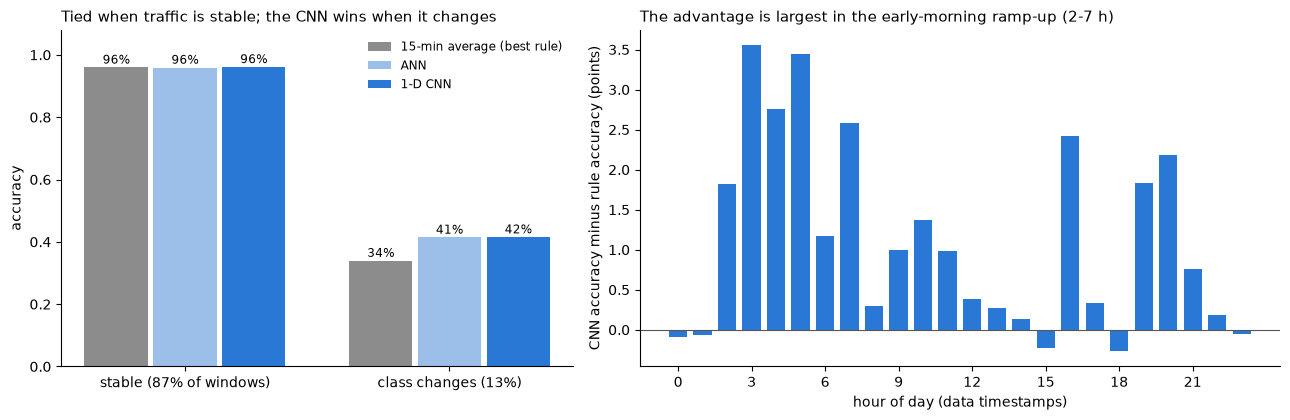

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
CNN gain (points),-0.09,-0.07,1.82,3.55,2.76,3.44,1.18,2.58,0.29,0.99,...,0.14,-0.23,2.42,0.34,-0.27,1.83,2.18,0.75,0.18,-0.06
% windows changing,0.10,0.50,6.10,11.00,13.70,14.30,16.90,18.90,19.00,22.90,...,12.20,11.80,16.50,15.30,16.80,17.10,13.30,5.60,1.80,0.40


In [8]:
d = np.load(DATA / "traffic_flow_preprocessed.npz")
X, y, s, t = d["X_test_seq"], d["y_test"].astype(int), d["sensor_test"], d["time_test"]
FLOW = 0
flow = X[:, :, FLOW] * d["feature_std"][s, FLOW][:, None] + d["feature_mean"][s, FLOW][:, None]
to_class = lambda f: np.where(f <= d["low_th"][s], 0, np.where(f <= d["high_th"][s], 1, 2))
persistence, avg15 = to_class(flow[:, -1]), to_class(flow[:, -3:].mean(axis=1))
assert (cnn["y_true"] == y).all() and (ann["y_true"] == y).all(), "prediction files are not aligned with the test set"

changing = y != persistence             # the class at the next step differs from the class now
preds = {"15-min average (best rule)": avg15, "ANN": ann["y_pred"], "1-D CNN": cnn["y_pred"]}
slices = pd.DataFrame({name: {"stable windows": np.mean(p[~changing] == y[~changing]),
                              "changing windows": np.mean(p[changing] == y[changing]),
                              "all windows": np.mean(p == y)} for name, p in preds.items()}).T
gain = (cnn["y_pred"] == y).astype(int) - (avg15 == y).astype(int)
share = gain[changing].sum() / gain.sum()
print(f"{changing.mean():.1%} of test windows change class at the next step ({changing.sum():,} of {len(y):,})")
print(f"CNN gain over the rule: {gain.mean():+.2%} overall, {share:.0%} of it from the changing windows")
fmt_p = lambda p: f"= {p:.1e}" if p > 0 else "< 1e-300 (below float precision)"
# McNemar test inside the changing slice: is the CNN's edge there real or noise?
cnn_ok, rule_ok = cnn["y_pred"][changing] == y[changing], avg15[changing] == y[changing]
b, c_ = int(np.sum(cnn_ok & ~rule_ok)), int(np.sum(~cnn_ok & rule_ok))
stat = (abs(b - c_) - 1) ** 2 / (b + c_)
print(f"Changing windows: CNN right & rule wrong {b:,}, rule right & CNN wrong {c_:,}, McNemar p {fmt_p(chi2.sf(stat, 1))}")
display(slices.style.format("{:.1%}"))

hour = (t % 288) // 12                  # 288 five-minute steps per day
by_hour = pd.DataFrame({"hour": hour, "gain": gain, "changing": changing}).groupby("hour").agg(
    gain=("gain", "mean"), changing=("changing", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [1, 1.25]})
colours = {"15-min average (best rule)": "#8c8c8c", "ANN": "#9cbfe9", "1-D CNN": "#2a78d6"}
xs = np.arange(2)
for i, (name, row) in enumerate(slices.iterrows()):
    bars = axes[0].bar(xs + (i - 1) * 0.26, row[["stable windows", "changing windows"]], 0.24, color=colours[name], label=name)
    for b in bars:
        axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012, f"{b.get_height():.0%}", ha="center", fontsize=8.5)
axes[0].set_xticks(xs, [f"stable ({1 - changing.mean():.0%} of windows)", f"class changes ({changing.mean():.0%})"])
axes[0].set_ylim(0, 1.08); axes[0].set_ylabel("accuracy")
axes[0].set_title("Tied when traffic is stable; the CNN wins when it changes", loc="left", fontsize=11)
axes[0].legend(fontsize=8.5, loc="upper right", frameon=False)
axes[1].bar(by_hour.index, by_hour.gain * 100, color="#2a78d6", width=0.75)
axes[1].axhline(0, color="#555555", lw=0.8)
axes[1].set_xticks(range(0, 24, 3)); axes[1].set_xlabel("hour of day (data timestamps)")
axes[1].set_ylabel("CNN accuracy minus rule accuracy (points)")
axes[1].set_title("The advantage is largest in the early-morning ramp-up (2-7 h)", loc="left", fontsize=11)
for ax in axes:
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "cnn_gain_breakdown.png"), dpi=160, bbox_inches="tight")
plt.show()
display(by_hour.assign(gain=lambda df: (df.gain * 100).round(2), changing=lambda df: (df.changing * 100).round(1))
        .rename(columns={"gain": "CNN gain (points)", "changing": "% windows changing"}).T)